In [1]:
import deepinv as dinv
import torch
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy.io as sio
mpl.rcParams.update(mpl.rcParamsDefault)
from PIL import Image
from deepinv.loss.metric import PSNR
perf_psnr = PSNR()
from scipy.io import loadmat
from scipy.io import savemat
import torch.nn as nn
from torch.utils.data import DataLoader
import time

from utils.gradient_descent import gradient_descent
from utils.database_gradient_descent import gradient_descent_database
from utils.load_data import load_data
from utils.fonction_dual_primal import CP_optim, CP_optim_fix, proxL1_norm, discrete_derivation, discrete_derivation_adj
from utils.create_database import CustomDataset, CustomDataset_window
from utils.CP_unfolded import cp_unfolded_OpLin as cp_oplin, cp_unfolded_l as cp, cp_unfolded_Lexp as cp_l, cp_unfolded_LSTexp as cp_lst
from utils.metric import metric, loss_L2
from utils.sliding_median import sliding_median
from utils.database_gradient_descent import load_model
from utils.config import TrainConfig

std
std
epoch 0/10000
epoch 100/10000
epoch 200/10000
epoch 300/10000
epoch 400/10000
epoch 500/10000
epoch 600/10000
epoch 700/10000
epoch 800/10000
epoch 900/10000
epoch 1000/10000
epoch 1100/10000
epoch 1200/10000
epoch 1300/10000
epoch 1400/10000
epoch 1500/10000
epoch 1600/10000
epoch 1700/10000
epoch 1800/10000
epoch 1900/10000
epoch 2000/10000
epoch 2100/10000
epoch 2200/10000
epoch 2300/10000
epoch 2400/10000
epoch 2500/10000
epoch 2600/10000
epoch 2700/10000
epoch 2800/10000
epoch 2900/10000
epoch 3000/10000
epoch 3100/10000
epoch 3200/10000
epoch 3300/10000
epoch 3400/10000
epoch 3500/10000
epoch 3600/10000
epoch 3700/10000
epoch 3800/10000
epoch 3900/10000
epoch 4000/10000
epoch 4100/10000
epoch 4200/10000
epoch 4300/10000
epoch 4400/10000
epoch 4500/10000
epoch 4600/10000
epoch 4700/10000
epoch 4800/10000
epoch 4900/10000
epoch 5000/10000
epoch 5100/10000
epoch 5200/10000
epoch 5300/10000
epoch 5400/10000
epoch 5500/10000
epoch 5600/10000
epoch 5700/10000
epoch 5800/10000
e

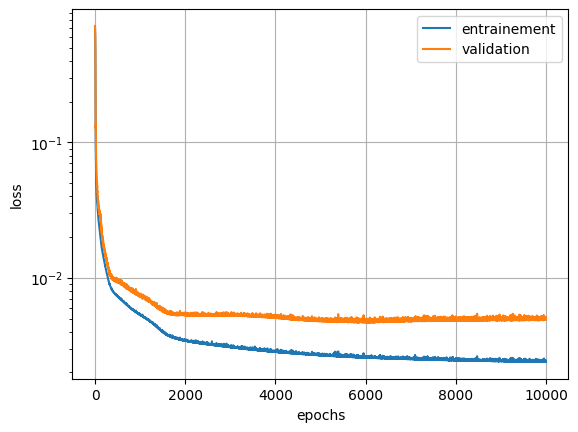

In [2]:
config_batch12_std = TrainConfig(
    device = "cuda",
    choix_model = 'OpLin_conv',
    choix_loss = 'L2',
    nepoch = 10000,
    K_layer = 10,
    nbatch_train = 360,
    nbatch_validation = 120,
    scheduler = False,
    learning_rate = 1e-4,
    optimizer = 'adam',
    largeur = 20,
    start_end_oplin_size = 10,
    dataset_train = '../dataset_covid/dataset_multi_gamma/from_5x_three_Z_nul',
    dataset_validation = '../dataset_covid/dataset_multi_gamma/from_5x_three_Z_nul_validation_rapport_stage',
    norm_type = 'std',
    R_init_type = 'ones',
    # init_param = 'database60_gamma_e001stdZ_conv20_10kepochs_wolr04_batch20_Rones.pth'
)

model_config1, model_best_config1, model_best_validation_config1, out_config1, loss_value_train_config1, loss_value_train_all_config1, loss_value_validation_config1, loss_value_validation_all_config1, dKL_value, metric_value, norm_value, norm_value_list_config1 = gradient_descent_database(config_batch12_std)

if config_batch12_std.scheduler == False:
    model_scheduler = None
else:
    model_scheduler = model_config1.scheduler.state_dict()

torch.save({
    'model_state_dict': model_config1.state_dict(),
    'optimizer_state_dict': model_config1.optimizer.state_dict(),
    'scheduler_state_dict': model_scheduler
}, f'database60_multi_gamma_all_conv20_wolr04_batch360_Rones_10kepochs.pth')

with torch.no_grad():
   dico = {'R' : out_config1, 'loss_train' : loss_value_train_config1, 'loss_validation' : loss_value_validation_config1, 'norm_grad' : norm_value_list_config1, 'loss_train_all' : loss_value_train_all_config1, 'loss_validation_all' : loss_value_validation_all_config1}
   savemat("database60_multi_gamma_all_conv20_wolr04_batch360_Rones_10kepochs.mat", dico)

plt.semilogy(loss_value_train_all_config1[:], label = 'entrainement')
plt.semilogy(loss_value_validation_all_config1[:], label = 'validation')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.legend()
plt.grid()
plt.show()

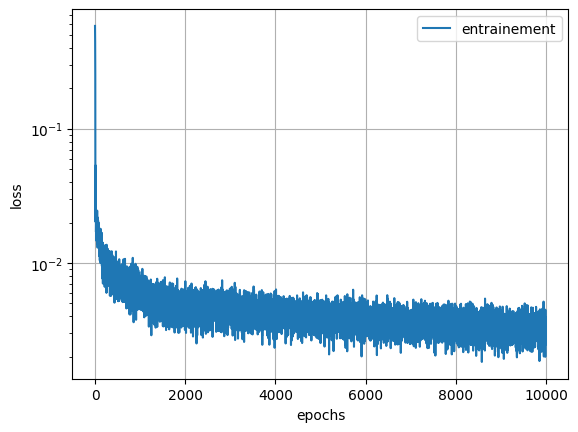

In [10]:
plt.semilogy(loss_value_train_config1[:], label = 'entrainement')
#plt.semilogy(loss_value_validation_config1[:], label = 'validation')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.legend()
plt.grid()
plt.show()

std
std
epoch 0/10000
epoch 1/10000
epoch 2/10000
epoch 3/10000
epoch 4/10000
epoch 5/10000
epoch 6/10000
epoch 7/10000
epoch 8/10000
epoch 9/10000
epoch 10/10000
epoch 11/10000
epoch 12/10000
epoch 13/10000
epoch 14/10000
epoch 15/10000
epoch 16/10000
epoch 17/10000
epoch 18/10000
epoch 19/10000
epoch 20/10000
epoch 21/10000
epoch 22/10000
epoch 23/10000
epoch 24/10000
epoch 25/10000
epoch 26/10000
epoch 27/10000
epoch 28/10000
epoch 29/10000
epoch 30/10000
epoch 31/10000
epoch 32/10000
epoch 33/10000
epoch 34/10000
epoch 35/10000
epoch 36/10000
epoch 37/10000
epoch 38/10000
epoch 39/10000
epoch 40/10000
epoch 41/10000
epoch 42/10000
epoch 43/10000
epoch 44/10000
epoch 45/10000
epoch 46/10000
epoch 47/10000
epoch 48/10000
epoch 49/10000
epoch 50/10000
epoch 51/10000
epoch 52/10000
epoch 53/10000
epoch 54/10000
epoch 55/10000
epoch 56/10000
epoch 57/10000
epoch 58/10000
epoch 59/10000
epoch 60/10000
epoch 61/10000
epoch 62/10000
epoch 63/10000
epoch 64/10000
epoch 65/10000
epoch 66/100

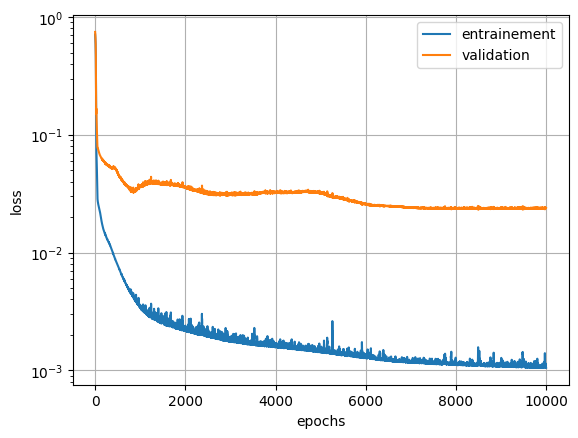

In [ ]:
config_batch12_std = TrainConfig(
    device = "cpu",
    choix_model = 'OpLin_conv',
    choix_loss = 'L2',
    nepoch = 10000,
    K_layer = 10,
    nbatch_train = 60,
    nbatch_validation = 12,
    scheduler = False,
    learning_rate = 1e-4,
    optimizer = 'adam',
    largeur = 20,
    dataset_train = '../dataset_covid/dataset10x/dataset10x_gamma_e0025stdZ',
    dataset_validation = '../dataset_covid/dataset10x/dataset10x_gamma_e0025stdZ_validation',
    norm_type = 'std',
    R_init_type = 'ones', 
    # init_param = 'database60_gamma_e001stdZ_conv20_10kepochs_wolr04_batch20_Rones.pth'
)

model_config1, model_best_config1, model_best_validation_config1, out_config1, loss_value_train_config1, loss_value_train_all_config1, loss_value_validation_config1, loss_value_validation_all_config1, dKL_value, metric_value, norm_value, norm_value_list_config1 = gradient_descent_database(config_batch12_std)

if config_batch12_std.scheduler == False:
    model_scheduler = None
else:
    model_scheduler = model_config1.scheduler.state_dict()

torch.save({
    'model_state_dict': model_config1.state_dict(),
    'optimizer_state_dict': model_config1.optimizer.state_dict(),
    'scheduler_state_dict': model_scheduler
}, f'database60_10x_gamma_e0025stdZ_conv20_10kepochs_wolr04_batch60_Rones.pth')

with torch.no_grad():
   dico_adam = {'R' : out_config1, 'loss_train' : loss_value_train_config1, 'loss_validation' : loss_value_validation_config1, 'norm_grad' : norm_value_list_config1, 'loss_train_all' : loss_value_train_all_config1, 'loss_validation_all' : loss_value_validation_all_config1}
   savemat("database60_10x_gamma_e0025stdZ_conv20_10kepochs_wolr04_batch60_Rones.mat", dico_adam)

plt.semilogy(loss_value_train_all_config1[:], label = 'entrainement')
plt.semilogy(loss_value_validation_all_config1[:], label = 'validation')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.legend()
plt.grid()
plt.show()

std
std
epoch 0/10000
epoch 1/10000
epoch 2/10000
epoch 3/10000
epoch 4/10000
epoch 5/10000
epoch 6/10000
epoch 7/10000
epoch 8/10000
epoch 9/10000
epoch 10/10000
epoch 11/10000
epoch 12/10000
epoch 13/10000
epoch 14/10000
epoch 15/10000
epoch 16/10000
epoch 17/10000
epoch 18/10000
epoch 19/10000
epoch 20/10000
epoch 21/10000
epoch 22/10000
epoch 23/10000
epoch 24/10000
epoch 25/10000
epoch 26/10000
epoch 27/10000
epoch 28/10000
epoch 29/10000
epoch 30/10000
epoch 31/10000
epoch 32/10000
epoch 33/10000
epoch 34/10000
epoch 35/10000
epoch 36/10000
epoch 37/10000
epoch 38/10000
epoch 39/10000
epoch 40/10000
epoch 41/10000
epoch 42/10000
epoch 43/10000
epoch 44/10000
epoch 45/10000
epoch 46/10000
epoch 47/10000
epoch 48/10000
epoch 49/10000
epoch 50/10000
epoch 51/10000
epoch 52/10000
epoch 53/10000
epoch 54/10000
epoch 55/10000
epoch 56/10000
epoch 57/10000
epoch 58/10000
epoch 59/10000
epoch 60/10000
epoch 61/10000
epoch 62/10000
epoch 63/10000
epoch 64/10000
epoch 65/10000
epoch 66/100

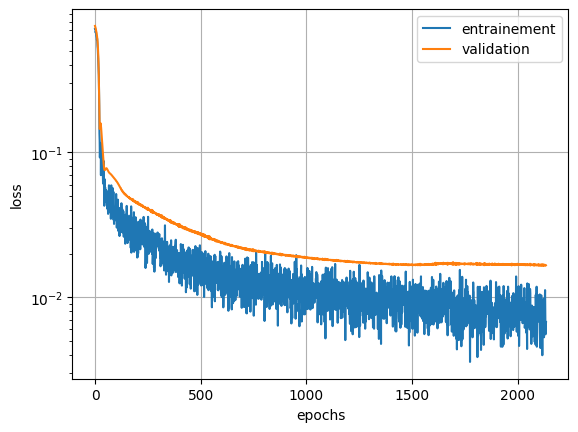

In [5]:
config_3 = TrainConfig(
    device = "cpu",
    choix_model = 'OpLin_conv',
    choix_loss = 'L2',
    nepoch = 10000,
    K_layer = 10,
    nbatch_train = 60,
    nbatch_validation = 12,
    scheduler = False,
    learning_rate = 1e-4,
    optimizer = 'adam',
    largeur = 20,
    dataset_train = 'dataset3x_gamma_e005medPhiZ',
    dataset_validation = 'dataset3x_gamma_e005medPhiZ_validation_rapport_stage',
    norm_type = 'std',
    R_init_type = 'ones', 
    # init_param = 'database60_gamma_e001stdZ_conv20_10kepochs_wolr04_batch20_Rones.pth'
)

model_config3, model_best_config3, model_best_validation_config3, out_config3, loss_value_train_config3, loss_value_train_all_config3, loss_value_validation_config3, loss_value_validation_all_config3, dKL_value, metric_value, norm_value, norm_value_list_config3 = gradient_descent_database(config_3)

if model_config3.scheduler == False:
    model_scheduler = None
else:
    model_scheduler = model_config3.scheduler.state_dict()

torch.save({
    'model_state_dict': model_config3.state_dict(),
    'optimizer_state_dict': model_config3.optimizer.state_dict(),
    'scheduler_state_dict': model_scheduler
}, f'database60_3x_gamma_e005medPhiZ_conv20_10kepochs_wolr04_batch60_Rones.pth')

with torch.no_grad():
   dico_adam = {'R' : out_config3, 'loss_train' : loss_value_train_config3, 'loss_validation' : loss_value_validation_config3, 'norm_grad' : norm_value_list_config3, 'loss_train_all' : loss_value_train_all_config3, 'loss_validation_all' : loss_value_validation_all_config3}
   savemat("database60_3x_gamma_e005medPhiZ_conv20_10kepochs_wolr04_batch60_Rones.mat", dico_adam)

plt.semilogy(loss_value_train_all_config3[:], label = 'entrainement')
plt.semilogy(loss_value_validation_all_config3[:], label = 'validation')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.legend()
plt.grid()
plt.show()

std
std
epoch 0/10000
epoch 1/10000
epoch 2/10000
epoch 3/10000
epoch 4/10000
epoch 5/10000
epoch 6/10000
epoch 7/10000
epoch 8/10000
epoch 9/10000
epoch 10/10000
epoch 11/10000
epoch 12/10000
epoch 13/10000
epoch 14/10000
epoch 15/10000
epoch 16/10000
epoch 17/10000
epoch 18/10000
epoch 19/10000
epoch 20/10000
epoch 21/10000
epoch 22/10000
epoch 23/10000
epoch 24/10000
epoch 25/10000
epoch 26/10000
epoch 27/10000
epoch 28/10000
epoch 29/10000
epoch 30/10000
epoch 31/10000
epoch 32/10000
epoch 33/10000
epoch 34/10000
epoch 35/10000
epoch 36/10000
epoch 37/10000
epoch 38/10000
epoch 39/10000
epoch 40/10000
epoch 41/10000
epoch 42/10000
epoch 43/10000
epoch 44/10000
epoch 45/10000
epoch 46/10000
epoch 47/10000
epoch 48/10000
epoch 49/10000
epoch 50/10000
epoch 51/10000
epoch 52/10000
epoch 53/10000
epoch 54/10000
epoch 55/10000
epoch 56/10000
epoch 57/10000
epoch 58/10000
epoch 59/10000
epoch 60/10000
epoch 61/10000
epoch 62/10000
epoch 63/10000
epoch 64/10000
epoch 65/10000
epoch 66/100

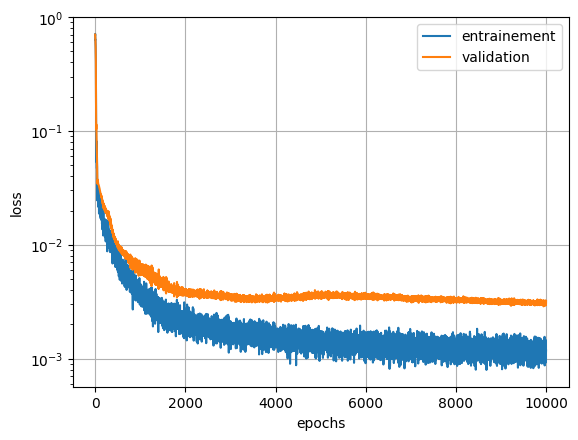

In [4]:
config_4 = TrainConfig(
    device = "cpu",
    choix_model = 'OpLin_conv',
    choix_loss = 'L2',
    nepoch = 10000,
    K_layer = 10,
    nbatch_train = 60,
    nbatch_validation = 12,
    scheduler = False,
    learning_rate = 1e-4,
    optimizer = 'adam',
    largeur = 20,
    dataset_train = 'dataset3x_gamma_e001medPhiZ',
    dataset_validation = 'dataset3x_gamma_e001medPhiZ_validation_rapport_stage',
    norm_type = 'std',
    R_init_type = 'ones', 
    # init_param = 'database60_gamma_e001stdZ_conv20_10kepochs_wolr04_batch20_Rones.pth'
)

model_config4, model_best_config4, model_best_validation_config4, out_config4, loss_value_train_config4, loss_value_train_all_config4, loss_value_validation_config4, loss_value_validation_all_config4, dKL_value, metric_value, norm_value, norm_value_list_config4 = gradient_descent_database(config_4)

if model_config4.scheduler == False:
    model_scheduler = None
else:
    model_scheduler = model_config4.scheduler.state_dict()

torch.save({
    'model_state_dict': model_config4.state_dict(),
    'optimizer_state_dict': model_config4.optimizer.state_dict(),
    'scheduler_state_dict': model_scheduler
}, f'database60_3x_gamma_e001medPhiZ_conv20_10kepochs_wolr04_batch60_Rones.pth')

with torch.no_grad():
   dico_adam = {'R' : out_config4, 'loss_train' : loss_value_train_config4, 'loss_validation' : loss_value_validation_config4, 'norm_grad' : norm_value_list_config4, 'loss_train_all' : loss_value_train_all_config4, 'loss_validation_all' : loss_value_validation_all_config4}
   savemat("database60_3x_gamma_e001medPhiZ_conv20_10kepochs_wolr04_batch60_Rones.mat", dico_adam)

plt.semilogy(loss_value_train_config4[:], label = 'entrainement')
plt.semilogy(loss_value_validation_config4[:], label = 'validation')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.legend()
plt.grid()
plt.show()

max
max
epoch 0/100000
epoch 1/100000
epoch 2/100000
epoch 3/100000
epoch 4/100000
epoch 5/100000
epoch 6/100000
epoch 7/100000
epoch 8/100000
epoch 9/100000
epoch 10/100000
epoch 11/100000
epoch 12/100000
epoch 13/100000
epoch 14/100000
epoch 15/100000
epoch 16/100000
epoch 17/100000
epoch 18/100000
epoch 19/100000
epoch 20/100000
epoch 21/100000
epoch 22/100000
epoch 23/100000
epoch 24/100000
epoch 25/100000
epoch 26/100000
epoch 27/100000
epoch 28/100000
epoch 29/100000
epoch 30/100000
epoch 31/100000
epoch 32/100000
epoch 33/100000
epoch 34/100000
epoch 35/100000
epoch 36/100000
epoch 37/100000
epoch 38/100000
epoch 39/100000
epoch 40/100000
epoch 41/100000
epoch 42/100000
epoch 43/100000
epoch 44/100000
epoch 45/100000
epoch 46/100000
epoch 47/100000
epoch 48/100000
epoch 49/100000
epoch 50/100000
epoch 51/100000
epoch 52/100000
epoch 53/100000
epoch 54/100000
epoch 55/100000
epoch 56/100000
epoch 57/100000
epoch 58/100000
epoch 59/100000
epoch 60/100000
epoch 61/100000
epoch 62/1

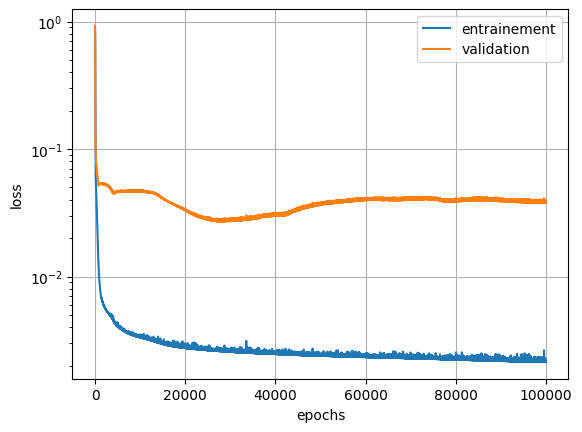

In [7]:
config_batch60_max_adamW = TrainConfig(
    device = "cpu",
    choix_model = 'OpLin_conv',
    choix_loss = 'L2',
    nepoch = 100000,
    K_layer = 10,
    nbatch = 60,
    scheduler = False,
    learning_rate = 1e-4,
    optimizer = 'adamW',
    largeur = 20,
    dataset_train = 'dataset',
    dataset_validation = 'dataset_validation_rapport_stage',
    norm_type = 'max'
)

model_config5, model_best_config5, model_best_validation_config5, out_config5, loss_value_train_config5, loss_value_validation_config5, dKL_value, metric_value, norm_value, norm_value_list_config5 = gradient_descent_database(config_batch60_max_adamW)

if config_batch60_max_adamW.scheduler == False:
    model_scheduler = None
else:
    model_scheduler = model_config5.scheduler.state_dict()

torch.save({
    'model_state_dict': model_config5.state_dict(),
    'optimizer_state_dict': model_config5.optimizer.state_dict(),
    'scheduler_state_dict': model_scheduler
}, f'database60_adamW_conv20_100kepochs_normmax_wolr04_batch30.pth')

with torch.no_grad():
   dico_adam = {'R' : out_config5, 'loss_train' : loss_value_train_config5, 'loss_validation' : loss_value_validation_config5, 'norm_grad' : norm_value_list_config5}
   savemat("database60_adamW_conv20_100kepochs_normmax_wolr04_batch30.mat", dico_adam)

plt.semilogy(loss_value_train_config5[:], label = 'entrainement')
plt.semilogy(loss_value_validation_config5[:], label = 'validation')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.legend()
plt.grid()
plt.show()

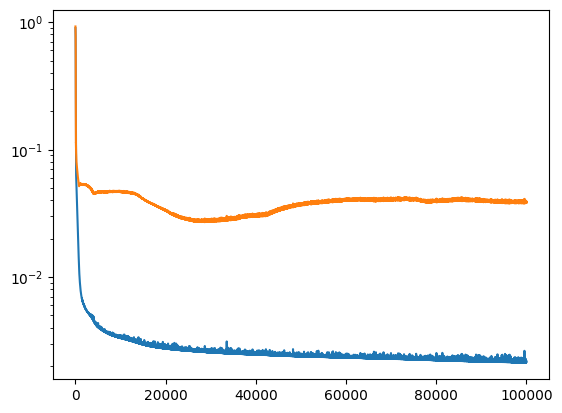

In [10]:
data = loadmat("database60_adamW_conv20_100kepochs_normmax_wolr04_batch30.mat", squeeze_me = True)
plt.semilogy(data['loss_train'])
plt.semilogy(data['loss_validation'])